# Notebook 9: Compound Repeats — NW-flex vs BWA-MEM

This notebook is the compound-repeat counterpart to Notebook 7. The reader is assumed to have just been through Notebook 7; here we surface only what is **new** to the compound case and refer back to Notebook 7 for everything that carries over unchanged.

The locus now contains two adjacent repeat blocks joined by a short bridge,
$$X = A \cdot R_1^{N_1} \cdot M \cdot R_2^{N_2} \cdot B,$$
and the haplotype varies both repeat counts independently as $(\Delta_1, \Delta_2)$. The compound-specific failure mode for BWA-MEM is a *bridge-anchoring* effect: a short bridge starves the seeder of anchor sequence between blocks, and the local extender then has to choose between near-tied alignments at both block boundaries. NW-flex's multi-block EP pattern is exhaustive over the product of allowed counts, so it is correct by construction whenever the only difference is the repeat counts.

## Setup

Same imports, scoring, and runtime requirements as Notebook 7. The only addition is `build_EP_multi_STR_phase` for the two-block NW-flex configuration.

In [1]:
get_ipython().run_line_magic('load_ext', 'autoreload')
get_ipython().run_line_magic('autoreload', '2')

from dataclasses import dataclass, field
from functools import reduce
from itertools import product
from pathlib import Path
from types import SimpleNamespace
from typing import List, Optional, Tuple
import shutil

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Patch, Rectangle

from nwflex.aligners import RefAligner
from nwflex.default import get_default_scoring
from nwflex.ep_patterns import build_EP_multi_STR_phase

from nwflex.simulation import (
    # carried over from Notebook 7
    clean_flank_window,
    tile_reads, mirror_reads, build_mirror_frame, reverse_complement,
    align_bwa, align_bwa_both_strands, align_nwflex,
    score_alignment, alignment_state, state_to_glyph, combine_states,
    parse_cigar, decode_z_bp, flank_bases_consumed,
    sweep, pivot_for_heatmap, SweepVariant,
    plot_correctness_heatmap, plot_correctness_heatmap_rows,
    # Compound-repeat primitives
    CompoundLocus, CompoundHaplotype,
    build_compound_locus_from_panel, build_compound_haplotype,
    build_compound_mirror_frame,
    is_arm_correct_multi,
    bwa_compound_truth_cigar, nwflex_compound_truth_cigar,
    alignment_state_multi,
    # Sweep adapters + 2-D plots
    wrap_methods_for_multizone_truth, aggregate_per_cell,
    plot_correctness_heatmap_2d, plot_correctness_heatmap_2d_rows,
    plot_proportion_heatmap_2d, plot_proportion_heatmap_2d_rows,
    plot_compound_layout_schematic,
)


In [2]:
# BWA-MEM-compatible scoring (+1 / -4 / -6 / -1) — same as Notebook 7.
score_matrix, gap_open, gap_extend, a2i = get_default_scoring("bwa_mem")
sc_kw = dict(score_matrix=score_matrix, gap_open=gap_open,
             gap_extend=gap_extend, alphabet_to_index=a2i)

In [3]:
required = ("bwa", "samtools")
missing = [t for t in required if shutil.which(t) is None]
print("Missing on PATH:" if missing else "Found on PATH:", ", ".join(missing or required))

Found on PATH: bwa, samtools


In [4]:
PANEL_PATH = Path("../data/hg38_motif_sample_K100.tsv")
panel = pd.read_csv(PANEL_PATH, sep="\t")
print(f"Loaded {len(panel):,} loci from {PANEL_PATH}")

Loaded 6,900 loci from ../data/hg38_motif_sample_K100.tsv


## Simulation

Four stages as in Notebook 7: **reference → haplotype → reads → mirror**. What is new:

- The **reference** stage now builds a compound locus $(A, R_1, N_1, M, R_2, N_2, B)$ and packs the NW-flex extended reference $(3N_1, 3N_2)$ alongside it, all in one object.
- The **haplotype** stage takes a pair $(\Delta_1, \Delta_2)$ instead of a single $\Delta$.
- **Reads** and **mirror** carry over from Notebook 7; the mirror frame now reverses two zones instead of one.

The schematic below previews the compound layout: outer flanks $A, B$, the two repeat blocks $R_1^{N_1}$ and $R_2^{N_2}$, and the bridge $M$ between them. The right panel shows the mirror frame used for strand-symmetric alignment.

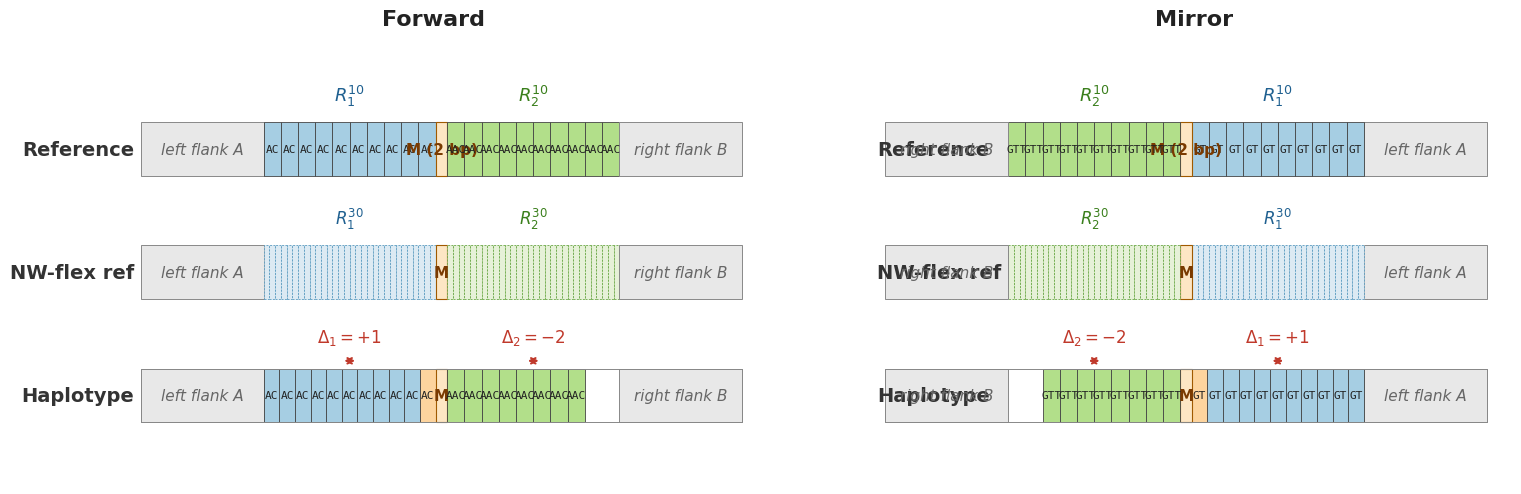

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(18.0, 5.6))
for ax_, mirror_ in zip(axes, [False, True]):
    plot_compound_layout_schematic(
        motif1="AC", motif2="AAC",
        ref_n1=10, ref_n2=10, bridge_len=2,
        delta1_example=+1, delta2_example=-2,
        mirror=mirror_,
        suptitle="Forward" if not mirror_ else "Mirror",
        ax=ax_,
    )


### Reference

A compound locus draws two distinct panel rows: from row 1 we keep $A$ (left flank) and $R_1$ (motif); from row 2 we keep $B$ (right flank) and $R_2$. The bridge $M$ is composed from the *interior* edges of the two rows' panel flanks (the inner end of row 1's right flank and the inner end of row 2's left flank), each cleaned against its adjacent motif. Bridge length is small on purpose — that is where the BWA bridge-anchoring failure mode lives.

`build_compound_locus_from_panel` returns a `CompoundLocus` carrying both the $N_1, N_2$ reference sequence (used by BWA) and the $3N_1, 3N_2$ extended reference (used by NW-flex), plus the offsets for both repeat zones in each.

In [6]:
compound = build_compound_locus_from_panel(
    panel,
    motif1_len=2, motif2_len=3,
    ref_n1=10, ref_n2=10,
    bridge_n1=1, bridge_n2=1,
    flank_len=200,
)

print(f"R1={compound.R1!r}  R2={compound.R2!r}  |M|={len(compound.M)}  M={compound.M!r}")
print(f"BWA ref     : |X|={len(compound.X)}      zones={compound.zones}")
print(f"NW-flex ref : |X_ext|={len(compound.X_ext)}  zones={compound.zones_ext}  "
      f"(factor={compound.nwflex_factor})")

R1='AC'  R2='AAC'  |M|=2  M='CA'
BWA ref     : |X|=452      zones=[(200, 220), (222, 252)]
NW-flex ref : |X_ext|=552  zones=[(200, 260), (262, 352)]  (factor=3)


### Haplotype

The haplotype shares the reference's flanks, motifs, and bridge but varies both repeat counts: $$X' = A \cdot R_1^{N_1 + \Delta_1} \cdot M \cdot R_2^{N_2 + \Delta_2} \cdot B$$ Optional flank SNVs follow the same convention as Notebook 7.

In [7]:
hap = build_compound_haplotype(compound, delta1=+1, delta2=-2)

print(f"hap N1+Δ1={compound.N1 + hap.delta1}  N2+Δ2={compound.N2 + hap.delta2}")
print(f"hap length: {len(hap.sequence)}  "
      f"({hap.flank_len} flank + {hap.body_len} body + "
      f"{len(hap.sequence) - hap.flank_len - hap.body_len} flank)")
print(f"per-block body lengths: {hap.body_lens} bp")

hap N1+Δ1=11  N2+Δ2=8
hap length: 448  (200 flank + 48 body + 200 flank)
per-block body lengths: (22, 24) bp


### Reads

Same `tile_reads` as Notebook 7 — no compound-specific change.

In [8]:
READ_LEN = 150
K_MIN_FLANK = 1
READ_STEP = 1

reads = tile_reads(hap, read_len=READ_LEN, k_min_flank=K_MIN_FLANK)
print(f"Tiled {len(reads)} reads (read_len={READ_LEN}, k_min_flank={K_MIN_FLANK})")

Tiled 101 reads (read_len=150, k_min_flank=1)


### Mirror

Same `build_mirror_frame` as Notebook 7, with one wrinkle: there are now two repeat zones, so the mirror call returns two mirrored zones in the same order. The aligner harnesses are still orientation-agnostic — the forward/mirror split lives entirely in the simulation.

In [9]:
rc_X, rc_X_ext, rc_reads, rc_zones, rc_zones_ext = build_compound_mirror_frame(
    compound, reads,
)

print(f"forward zones      : {compound.zones}")
print(f"mirror  zones      : {rc_zones}")
print(f"forward zones (ext): {compound.zones_ext}")
print(f"mirror  zones (ext): {rc_zones_ext}")


forward zones      : [(200, 220), (222, 252)]
mirror  zones      : [(232, 252), (200, 230)]
forward zones (ext): [(200, 260), (262, 352)]
mirror  zones (ext): [(292, 352), (200, 290)]


## BWA-MEM, two ways

The two BWA-MEM configurations carry over unchanged from Notebook 7 — **standard** (soft-clipping allowed under defaults) and **no-clip** (`-L 500`, clipping never improves the score). BWA does not need to know about the compound structure: the index is built once over the compound reference, and `bwa mem` is run on the reads. The compound layout schematic above already shows where both block boundaries sit and where the bridge $M$ falls between them.

In [10]:
# Three illustrative reads spanning both block boundaries.
illustrative_idx = [0, len(reads) // 2, len(reads) - 1]
illustrative_reads        = [reads[i]    for i in illustrative_idx]
illustrative_mirror_reads = [rc_reads[i] for i in illustrative_idx]

bwa_std_fwd    = align_bwa(compound.X, illustrative_reads,        no_clip=False)
bwa_std_rc     = align_bwa(rc_X,       illustrative_mirror_reads, no_clip=False)
bwa_noclip_fwd = align_bwa(compound.X, illustrative_reads,        no_clip=True)
bwa_noclip_rc  = align_bwa(rc_X,       illustrative_mirror_reads, no_clip=True)

for tag, hit in zip(("std fwd", "std rc", "no-clip fwd", "no-clip rc"),
                    (bwa_std_fwd[1], bwa_std_rc[1],
                     bwa_noclip_fwd[1], bwa_noclip_rc[1])):
    print(f"  middle-read {tag:>12s}: pos={hit.pos} CIGAR={hit.cigar} AS={hit.score}")

  middle-read      std fwd: pos=150 CIGAR=71M3D4M1D75M AS=129
  middle-read       std rc: pos=150 CIGAR=74M2D5M2D71M AS=129
  middle-read  no-clip fwd: pos=150 CIGAR=71M3D4M1D75M AS=129
  middle-read   no-clip rc: pos=150 CIGAR=74M2D5M2D71M AS=129


## NW-flex

The only compound-specific change on the NW-flex side is the EP pattern. Where Notebook 7 used a single-block STR EP, here we use `build_EP_multi_STR_phase`, which is the row-wise union of per-block EP sets — one DP pass enumerates the full Cartesian product of allowed $(N_1 + \Delta_1, N_2 + \Delta_2)$ counts against the extended $(3N_1, 3N_2)$ reference.

In [11]:
ep_fwd = build_EP_multi_STR_phase(
    n=len(compound.X_ext),
    blocks=[
        (compound.zones_ext[0][0], compound.zones_ext[0][1], compound.k1),
        (compound.zones_ext[1][0], compound.zones_ext[1][1], compound.k2),
    ],
)
ep_rc = build_EP_multi_STR_phase(
    n=len(rc_X_ext),
    blocks=[
        (rc_zones_ext[0][0], rc_zones_ext[0][1], compound.k1),
        (rc_zones_ext[1][0], rc_zones_ext[1][1], compound.k2),
    ],
)

nwflex_fwd = align_nwflex(
    compound.X_ext, illustrative_reads,
    extra_predecessors=ep_fwd, **sc_kw,
)
nwflex_rc = align_nwflex(
    rc_X_ext, illustrative_mirror_reads,
    extra_predecessors=ep_rc, **sc_kw,
)

for tag, hit in zip(("fwd", "rc"), (nwflex_fwd[1], nwflex_rc[1])):
    print(f"  middle-read NW-flex {tag}: pos={hit.pos} CIGAR={hit.cigar} score={hit.score}")

  middle-read NW-flex fwd: pos=150 CIGAR=51M38N24M66N75M score=150.0
  middle-read NW-flex rc: pos=150 CIGAR=51M66N26M38N73M score=150.0


## Two scoring conventions

Same SW / NW split as Notebook 7 — no compound-specific behavior. We rescore every alignment under NW (`score_alignment`) before comparing, so BWA's SW-vs-NW gap at boundary cells does not leak into the verdict. See the corresponding section of Notebook 7 for the worked example.

## Two-level correctness

Same two-axis framing as Notebook 7, lifted to the compound case:

1. **Length correctness** — the chosen CIGAR must span *both* repeat zones and recover the truth's repeat length in *each* block. The single-block `is_arm_correct` becomes `is_arm_correct_multi`, which returns a per-block length verdict plus an overall (both-blocks-correct) verdict.
2. **Score relationship** — unchanged. We compare the chosen alignment's NW score to the compound truth alignment's NW score: $<$, $=$, $>$.

The compound truth alignment is built from the haplotype $(\Delta_1, \Delta_2)$: match through $A$, gap of $|\Delta_1| \cdot |R_1|$ at the right edge of block 1, match through $M$, gap of $|\Delta_2| \cdot |R_2|$ at the right edge of block 2, match through $B$. Same construction shape as the NB7 truth, applied twice.

## Sweeps and results

Both sweeps re-use Notebook 7's `sweep` / `pivot_for_heatmap` harness. The harness is variant-shape-agnostic — each `SweepVariant` carries an arbitrary `label` dict, so `{"delta1": d1, "delta2": d2}` for the grid and `{"delta1": d1, "delta2": d2, "bridge_len": m}` for the bridge sweep drop in without changes to the harness itself. What we *do* need is the compound `methods` block (closures over the compound references and the compound truth-CIGAR builders) and a 2-D heatmap renderer that takes $\Delta_1 \times \Delta_2$ axes instead of $\Delta \times$ lflank.

### $(\Delta_1, \Delta_2)$ sweep

Three pieces: (a) a `methods` list for the harness, with `run / truth / classify` closures bound to the compound references; (b) a variant builder that walks the cartesian product of $(\Delta_1, \Delta_2)$; (c) one call to `sweep` and one to `pivot_for_heatmap`, exactly as in Notebook 7.

The classify closures call `alignment_state_multi` so the per-block length verdict and the truth-score comparison both use the compound truth alignment.

In [12]:
# Sweep parameters
DELTAS1 = list(range(-5, 6))
DELTAS2 = list(range(-5, 6))
READ_LEN = 150
K_MIN_FLANK = 1
COMBINE = "best"


def _build_compound_methods(compound, rc_X, rc_X_ext, rc_zones, rc_zones_ext,
                            ep_fwd, ep_rc):
    """Compound `methods` list for the sweep harness. Same shape as
    NB7's `_build_compound_methods`, with references and truth-CIGAR
    builders swapped for compound ones."""
    bwa_zones_fwd = compound.zones
    bwa_zones_rc  = rc_zones
    nwf_zones_fwd = compound.zones_ext
    nwf_zones_rc  = rc_zones_ext

    def _bwa_run(reads, orient, *, no_clip):
        if orient == "fwd":
            return align_bwa(compound.X, reads, no_clip=no_clip)
        return     align_bwa(rc_X, mirror_reads(reads), no_clip=no_clip)

    def _bwa_truth(r, hap):
        pos, cig = bwa_compound_truth_cigar(r, hap, compound)
        return score_alignment(r.sequence, compound.X, pos, cig, **sc_kw)

    def _bwa_classify(hit, r, truth_score, truth_z_bps, orient):
        if orient == "fwd":
            seq, ref, zones = r.sequence, compound.X, bwa_zones_fwd
        else:
            seq, ref, zones = reverse_complement(r.sequence), rc_X, bwa_zones_rc
        chosen = (
            None if hit.cigar is None or hit.pos is None
            else score_alignment(seq, ref, hit.pos, hit.cigar, **sc_kw)
        )
        return alignment_state_multi(
            hit.cigar, hit.pos, chosen, truth_score, zones, truth_z_bps,
            convention="bwa",
        )

    def _nwflex_run(reads, orient):
        if orient == "fwd":
            return align_nwflex(compound.X_ext, reads,
                                extra_predecessors=ep_fwd, **sc_kw)
        return     align_nwflex(rc_X_ext, mirror_reads(reads),
                                extra_predecessors=ep_rc, **sc_kw)

    def _nwflex_truth(r, hap):
        pos, cig = nwflex_compound_truth_cigar(r, hap, compound)
        return score_alignment(r.sequence, compound.X_ext, pos, cig, **sc_kw)

    def _nwflex_classify(hit, r, truth_score, truth_z_bps, orient):
        zones = nwf_zones_fwd if orient == "fwd" else nwf_zones_rc
        return alignment_state_multi(
            hit.cigar, hit.pos, float(hit.score), truth_score,
            zones, truth_z_bps, convention="nwflex",
        )

    return [
        SimpleNamespace(
            name="BWA-std",
            run=lambda rs, o: _bwa_run(rs, o, no_clip=False),
            truth=_bwa_truth, classify=_bwa_classify,
        ),
        SimpleNamespace(
            name="BWA-no-clip",
            run=lambda rs, o: _bwa_run(rs, o, no_clip=True),
            truth=_bwa_truth, classify=_bwa_classify,
        ),
        SimpleNamespace(
            name="NW-flex",
            run=_nwflex_run,
            truth=_nwflex_truth, classify=_nwflex_classify,
        ),
    ]


methods = _build_compound_methods(
    compound, rc_X, rc_X_ext, rc_zones, rc_zones_ext, ep_fwd, ep_rc,
)


def _make_compound_variant(compound, delta1, delta2):
    hap = build_compound_haplotype(compound, delta1=delta1, delta2=delta2)
    reads_v = tile_reads(hap, read_len=READ_LEN, k_min_flank=K_MIN_FLANK, step=READ_STEP)
    return SweepVariant(
        label={"delta1": delta1, "delta2": delta2},
        hap=hap, reads=reads_v,
    )

In [13]:
variants = [_make_compound_variant(compound, d1, d2)
            for d1, d2 in product(DELTAS1, DELTAS2)]

long_df = sweep(
    variants,
    wrap_methods_for_multizone_truth(methods, variants),
)
grid_df = pivot_for_heatmap(long_df, combine=COMBINE)

cell_df = aggregate_per_cell(grid_df, ["arm", "delta1", "delta2"])
print(f"Sweep: {len(DELTAS1)} d1 x {len(DELTAS2)} d2 x "
      f"{len(methods)} arms = {len(cell_df)} per-cell verdicts "
      f"(strand aggregation 'best', combine 'best')")
cell_df.groupby('arm')['state'].value_counts().unstack(fill_value=0)


Sweep: 11 d1 x 11 d2 x 3 arms = 363 per-cell verdicts (strand aggregation 'best', combine 'best')


state,D,P,T
arm,,,
BWA-no-clip,43,41,37
BWA-std,17,88,16
NW-flex,0,121,0


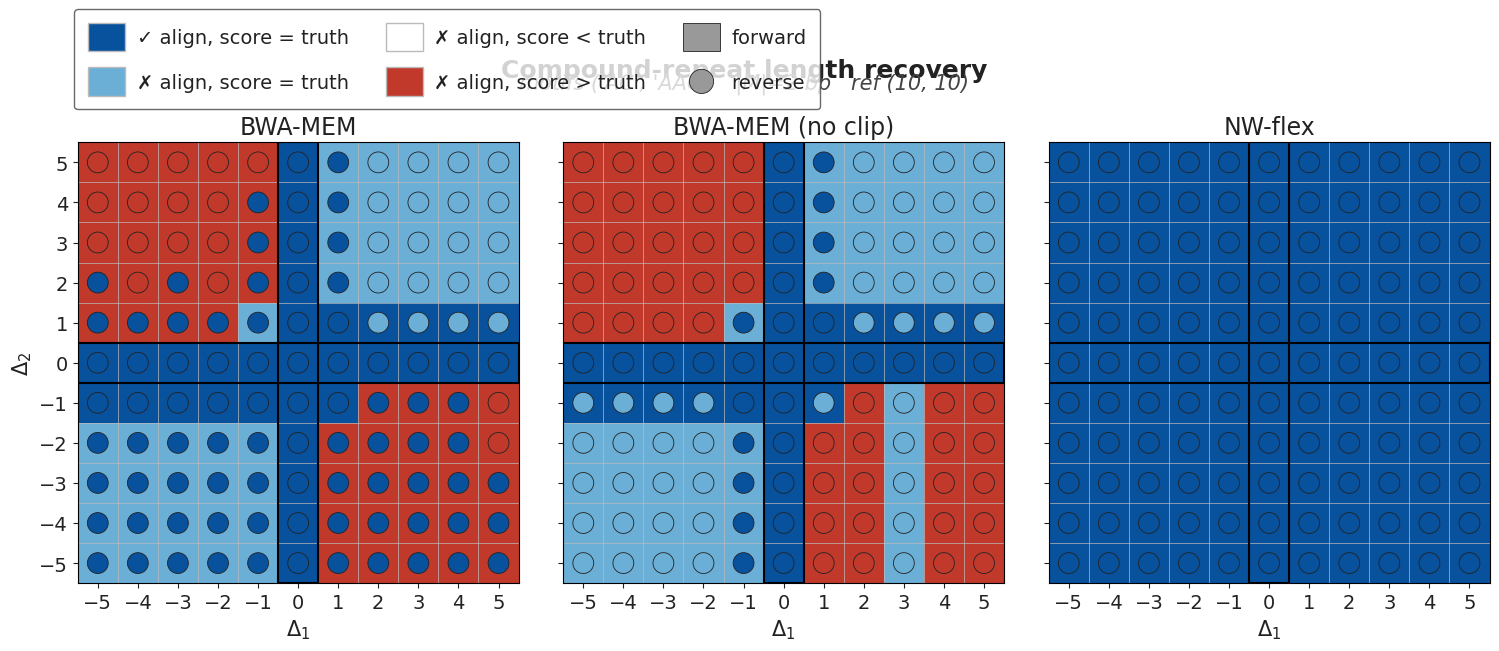

In [14]:
ARM_TITLES = {
    "BWA-std":     "BWA-MEM",
    "BWA-no-clip": "BWA-MEM (no clip)",
    "NW-flex":     "NW-flex",
}

plot_correctness_heatmap_2d(
    grid_df,
    deltas1=DELTAS1, deltas2=DELTAS2,
    arm_titles=ARM_TITLES,
    combine_across_reads="best",
    suptitle="Compound-repeat length recovery",
    subtitle=(f"motifs ({compound.R1!r}, {compound.R2!r})"
              f"   |M|={len(compound.M)} bp"
              f"   ref ({compound.N1}, {compound.N2})"),
);


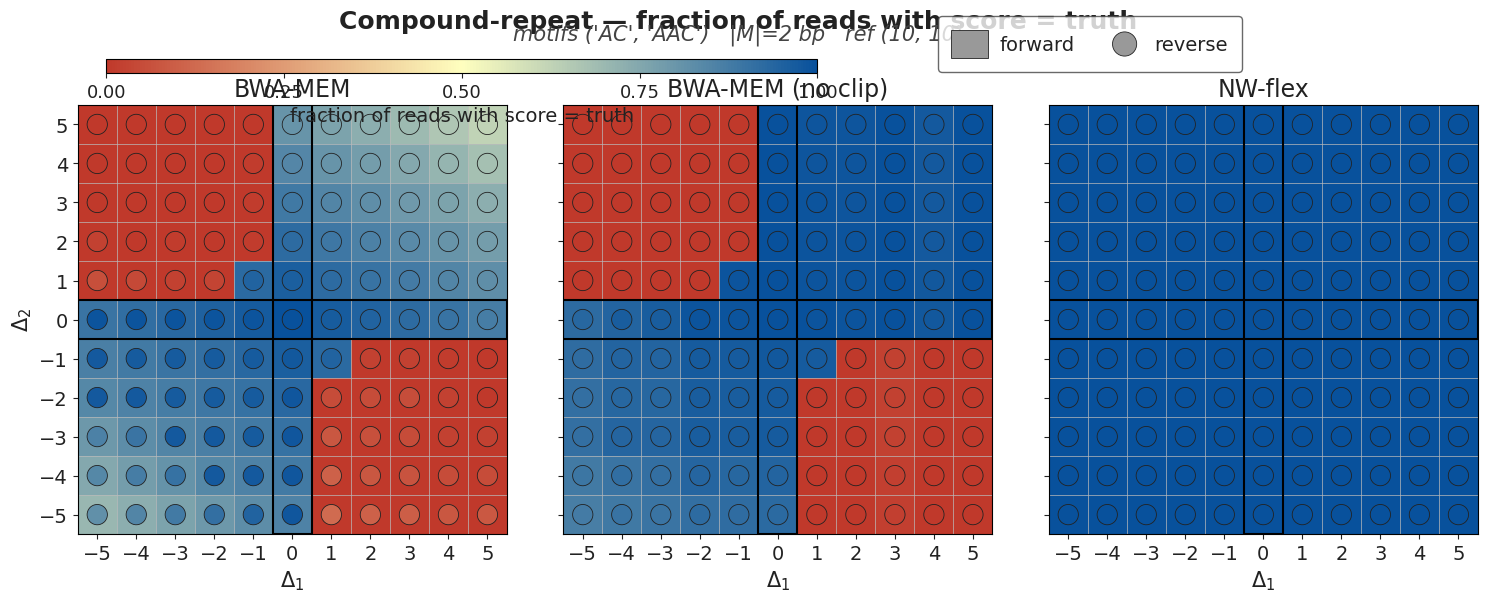

In [15]:
plot_proportion_heatmap_2d(
    grid_df,
    deltas1=DELTAS1, deltas2=DELTAS2,
    arm_titles=ARM_TITLES,
    suptitle="Compound-repeat — fraction of reads with score = truth",
    subtitle=(f"motifs ({compound.R1!r}, {compound.R2!r})"
              f"   |M|={len(compound.M)} bp"
              f"   ref ({compound.N1}, {compound.N2})"),
);


### Bridge-length effect

Outer loop over $|M|$: rebuild the compound (and the rc frame, and the multi-block EP), rebuild the `methods` block bound to the new references, then re-run the same $(\Delta_1, \Delta_2)$ sweep. Each sweep's long-form output is tagged with its `bridge_len` and concatenated, so the stacked heatmap consumes exactly one pivoted DataFrame.

In [16]:
# Match NB8: explicit (bridge_n1, bridge_n2) pairs yielding |M| ∈ {2,3,4,5}.
BRIDGE_PAIRS = [(1, 1), (2, 1), (2, 2), (3, 2)]
BRIDGE_LENGTHS = [n1 + n2 for n1, n2 in BRIDGE_PAIRS]

bridge_long_frames = []
for (n1, n2), m_len in zip(BRIDGE_PAIRS, BRIDGE_LENGTHS):
    cmp_m = build_compound_locus_from_panel(
        panel,
        motif1_len=2, motif2_len=3,
        ref_n1=10, ref_n2=10,
        bridge_n1=n1, bridge_n2=n2,
        flank_len=200,
    )
    rc_X_m, rc_X_ext_m, _, rc_zones_m, rc_zones_ext_m = (
        build_compound_mirror_frame(cmp_m, [])
    )
    ep_fwd_m = build_EP_multi_STR_phase(
        n=len(cmp_m.X_ext),
        blocks=[
            (cmp_m.zones_ext[0][0], cmp_m.zones_ext[0][1], cmp_m.k1),
            (cmp_m.zones_ext[1][0], cmp_m.zones_ext[1][1], cmp_m.k2),
        ],
    )
    ep_rc_m = build_EP_multi_STR_phase(
        n=len(rc_X_ext_m),
        blocks=[
            (rc_zones_ext_m[0][0], rc_zones_ext_m[0][1], cmp_m.k1),
            (rc_zones_ext_m[1][0], rc_zones_ext_m[1][1], cmp_m.k2),
        ],
    )
    methods_m = _build_compound_methods(
        cmp_m, rc_X_m, rc_X_ext_m, rc_zones_m, rc_zones_ext_m,
        ep_fwd_m, ep_rc_m,
    )
    variants_m = [_make_compound_variant(cmp_m, d1, d2)
                  for d1, d2 in product(DELTAS1, DELTAS2)]
    sub_long = sweep(
        variants_m,
        wrap_methods_for_multizone_truth(methods_m, variants_m),
    )
    sub_long["bridge_len"] = m_len
    bridge_long_frames.append(sub_long)

bridge_long_df = pd.concat(bridge_long_frames, ignore_index=True)
bridge_df = pivot_for_heatmap(bridge_long_df, combine=COMBINE)

bridge_cell_df = aggregate_per_cell(
    bridge_df, ["bridge_len", "arm", "delta1", "delta2"],
)
print(f"Bridge sweep: {len(BRIDGE_LENGTHS)} bridge lengths x "
      f"{len(DELTAS1)} d1 x {len(DELTAS2)} d2 x {len(methods_m)} arms")
for m_len in BRIDGE_LENGTHS:
    sub = bridge_cell_df[bridge_cell_df["bridge_len"] == m_len]
    print(f"\n|M|={m_len} bp:")
    print(sub.groupby("arm")["state"].value_counts().unstack(fill_value=0)
          .reindex(columns=["P", "T", "M", "D"], fill_value=0).to_string())


Bridge sweep: 4 bridge lengths x 11 d1 x 11 d2 x 3 arms

|M|=2 bp:
state          P   T  M   D
arm                        
BWA-no-clip   41  37  0  43
BWA-std       88  16  0  17
NW-flex      121   0  0   0

|M|=3 bp:
state          P   T  M   D
arm                        
BWA-no-clip   42  12  4  63
BWA-std       88   0  0  33
NW-flex      121   0  0   0

|M|=4 bp:
state          P  T  M   D
arm                       
BWA-no-clip  108  1  0  12
BWA-std      116  0  0   5
NW-flex      121  0  0   0

|M|=5 bp:
state          P  T  M  D
arm                      
BWA-no-clip  121  0  0  0
BWA-std      121  0  0  0
NW-flex      121  0  0  0


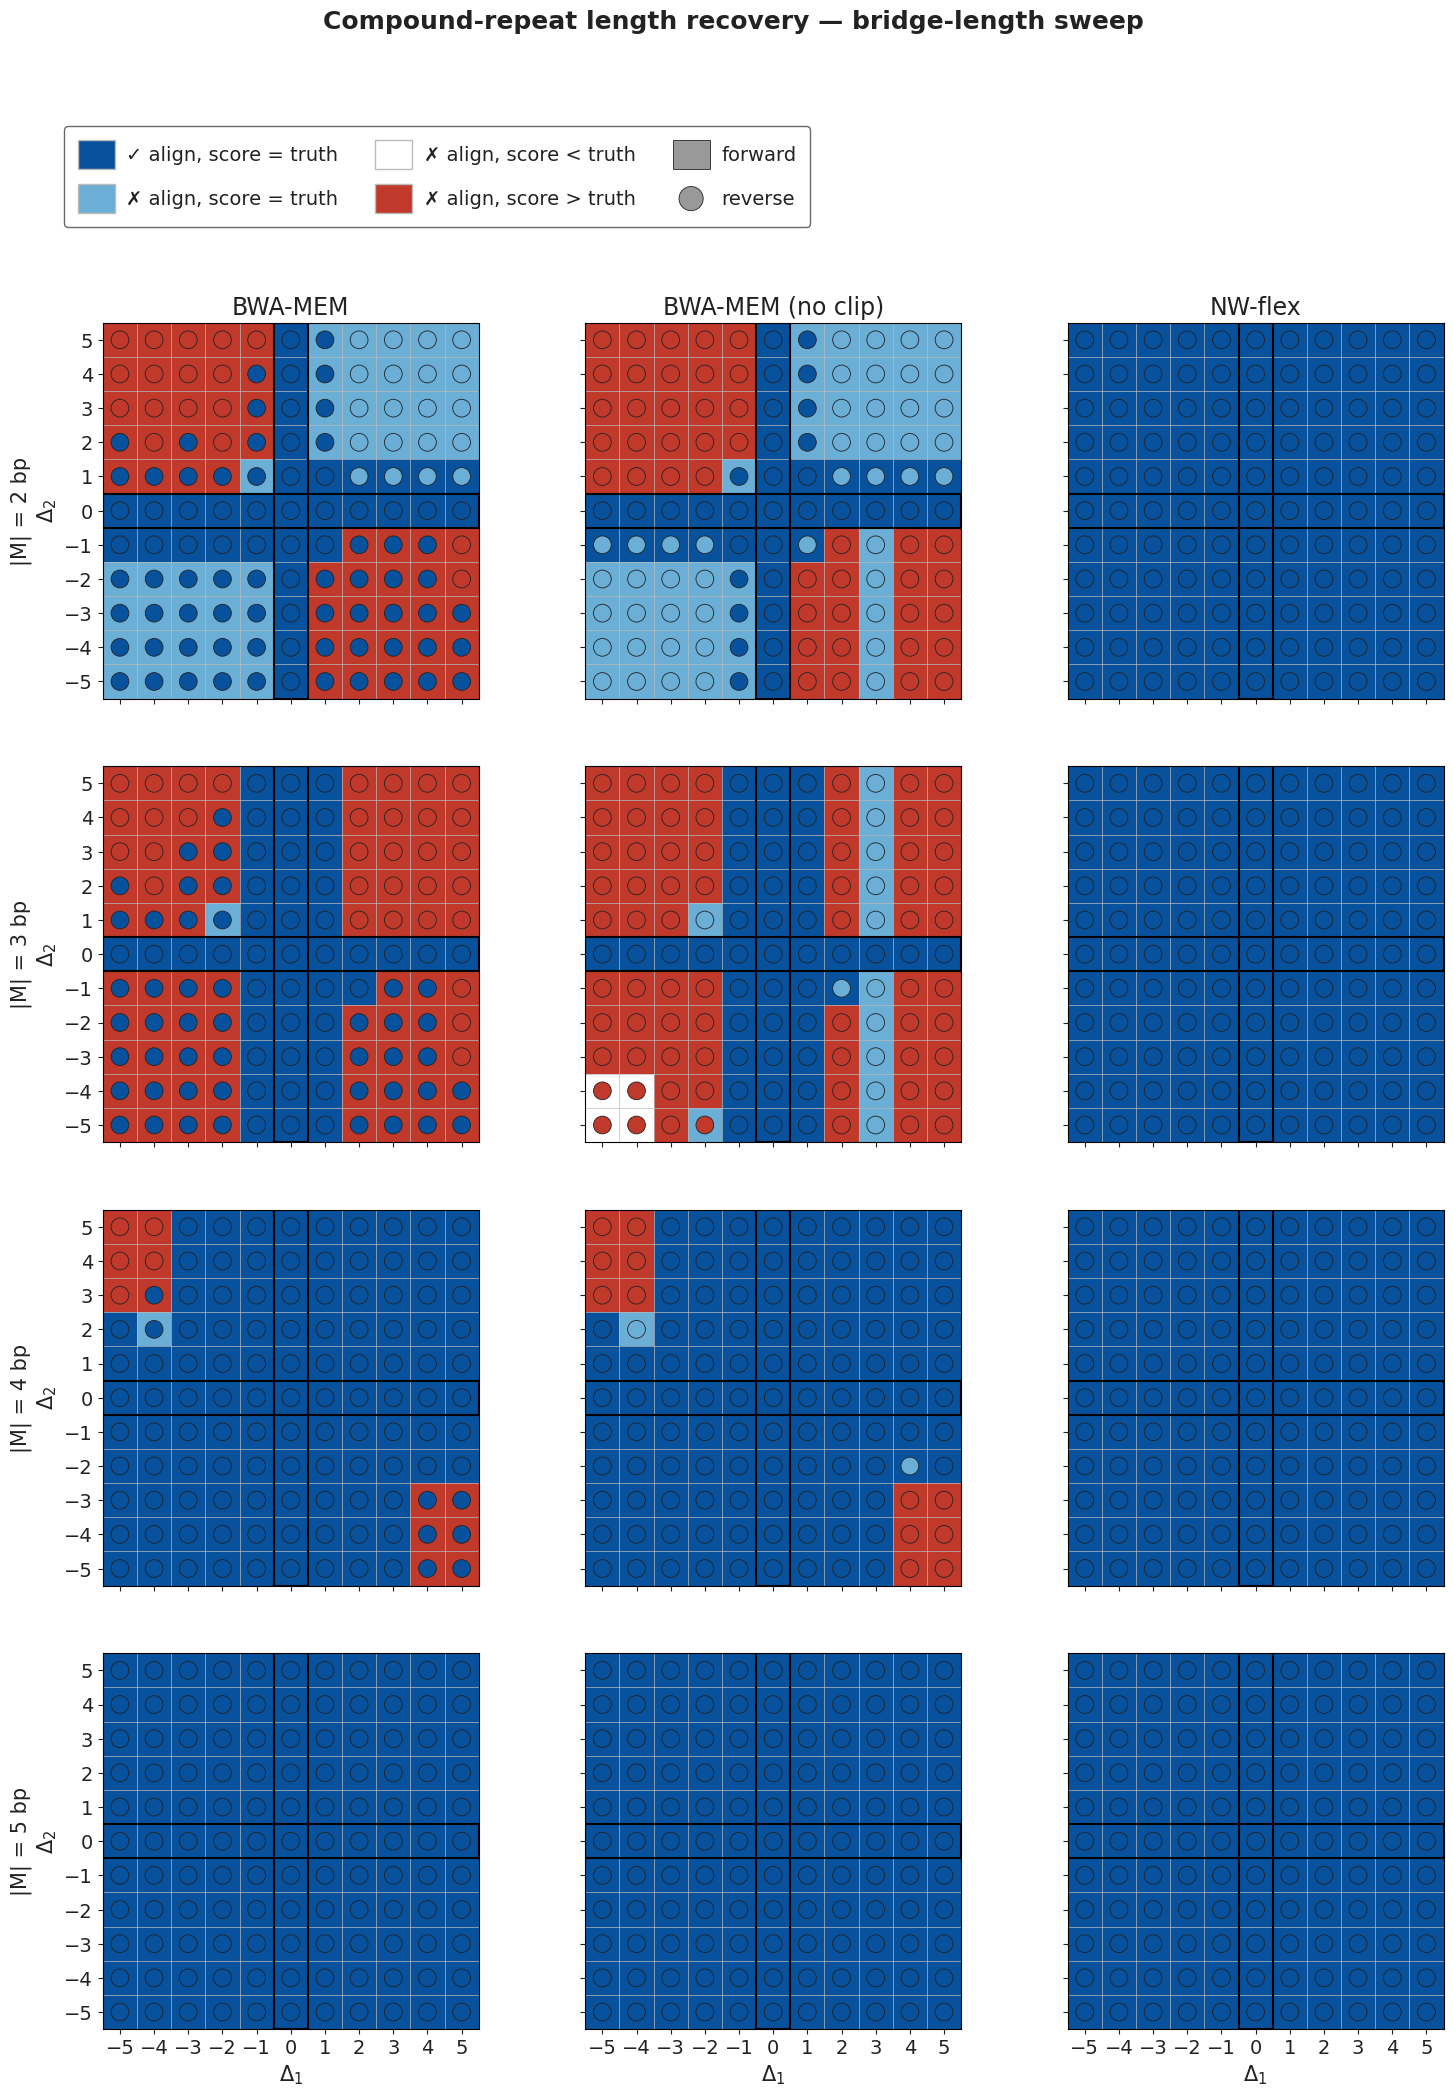

In [17]:
plot_correctness_heatmap_2d_rows(
    bridge_df,
    deltas1=DELTAS1, deltas2=DELTAS2,
    row_values=BRIDGE_LENGTHS, row_col="bridge_len",
    arm_titles=ARM_TITLES,
    row_label_fn=lambda m: f"|M| = {m} bp",
    combine_across_reads="best",
    suptitle="Compound-repeat length recovery — bridge-length sweep",
);

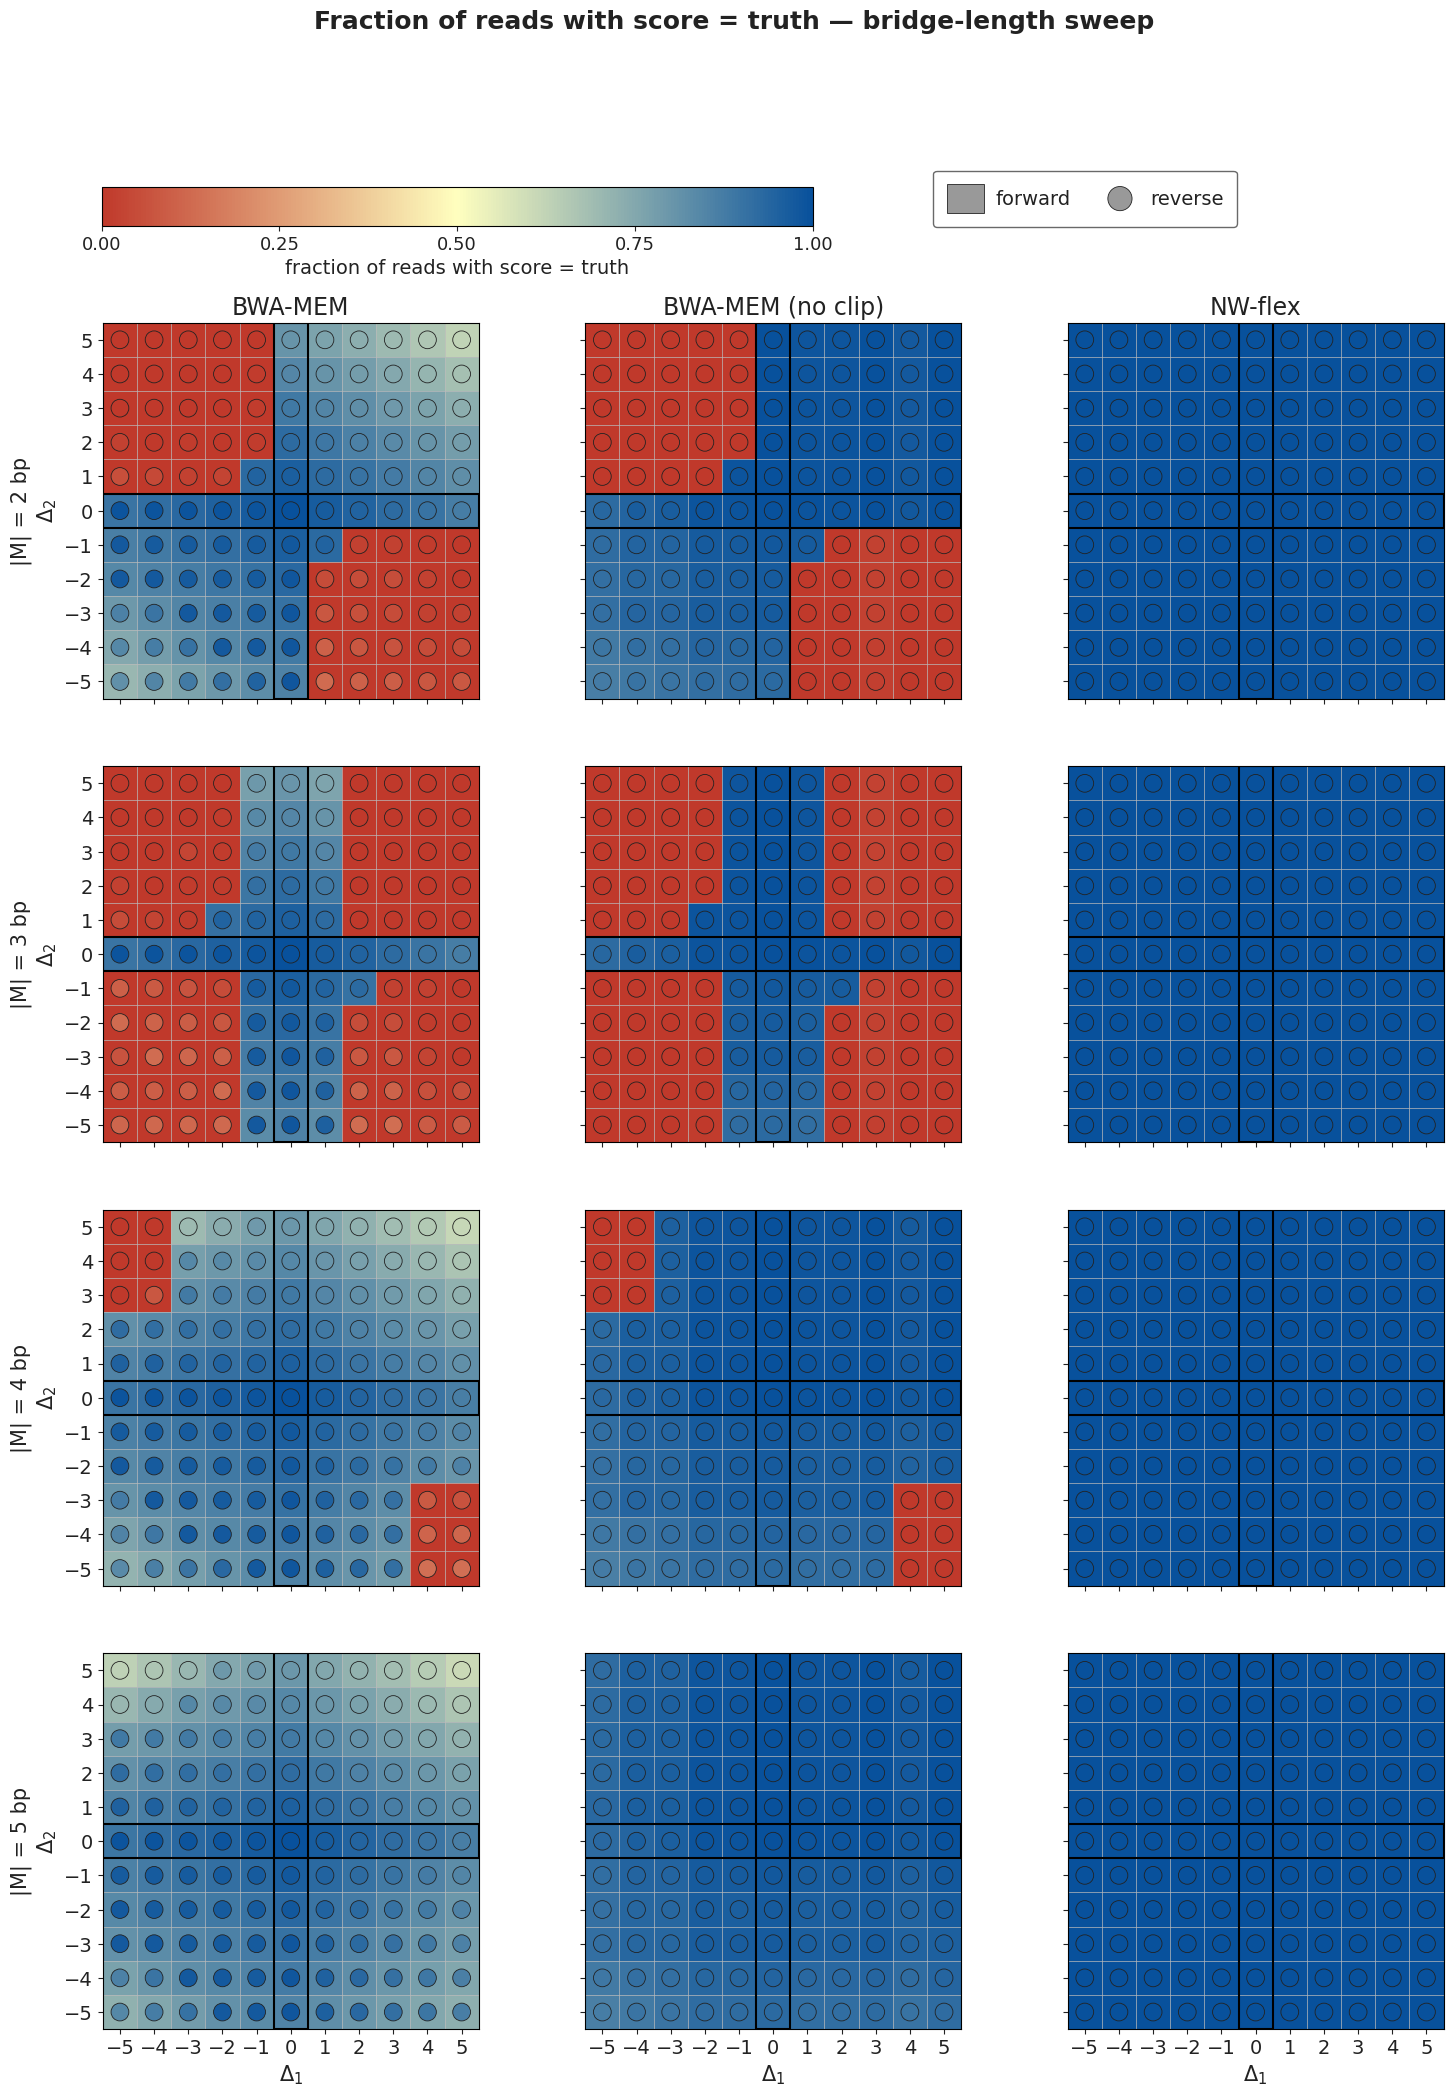

In [18]:
plot_proportion_heatmap_2d_rows(
    bridge_df,
    deltas1=DELTAS1, deltas2=DELTAS2,
    row_values=BRIDGE_LENGTHS, row_col="bridge_len",
    arm_titles=ARM_TITLES,
    row_label_fn=lambda m: f"|M| = {m} bp",
    suptitle="Fraction of reads with score = truth — bridge-length sweep",
);


## Summary

*(Placeholder — to be written once the sweeps are in.)*

- BWA's compound-repeat failure mode is a bridge-anchoring effect: short $|M|$ starves the seeder of anchor sequence between blocks; the per-block heuristic miss compounds across both boundaries.
- NW-flex is correct by construction on length-only compound sweeps: `build_EP_multi_STR_phase` is exhaustive over the product of allowed counts.
- The $|M|$ stack shows where BWA recovers (long bridge) versus where the compound story is visible (short bridge).